# Lab 2 Ghofran's code

In [18]:
#####################################
### Import the relevant libraries ###
#####################################
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA

## DATA
I have used the medicheck-expert.csv data set from ANTONIO work and did manual basic cleaning as follows:
1. Kept only the two needed columns: query, query-label-expert
2. Dropped exact duplicate rows
3. Ensured labels are numeric and in {0,1,2,3}, label distribution now is: {0: 4, 1: 1226, 2: 152, 3: 34}

In [ ]:
####################################
##### Load the cleaned dataset #####
####################################
df = pd.read_csv("cleaned_medicheck-expert.csv")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())


Dataset shape: (1416, 2)
Columns: ['query', 'query-label-expert']
                                               query  query-label-expert
0  Why do i get a bad headache when i don't eat e...                   2
1  What causes heart rate to suddenly quicken to ...                   2
2  peritonsillar abscess drainage aftercare.. ple...                   2
3  How serious is Mono or tonsillitis when untrea...                   2
4      What are your chances of dying in your sleep?                   1


## Relabel according to ANTONIO
The query-label-expert column has 4 classes:

**0**: not medical query, **1**: mild medical seriousness, **2**: serious medical, **3**: very serious medical.

Just like ANTONIO we don't care about the levels of severity, instead, we are reducing the problem to binary classification:

**Medical query (positive) → label 0**, if the query is medical (any of 1, 2, or 3), ANTONIO remaps it to 0.

**Not medical query (negative) → label 1**, if the query is non-medical (originally 0), ANTONIO remaps it to 1.

In [13]:
#########################################
# Relabel the data & visualize examples #
#########################################  
def antonio_relabel(x):
    if x in [1, 2, 3]:   # any medical query
        return 0         # medical
    elif x == 0:         # not medical
        return 1
    else:
        return np.nan

df["label"] = df["query-label-expert"].apply(antonio_relabel)
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)
print("Label distribution after relabelling:\n", df["label"].value_counts())

# Show a few random examples
print("\nRandom examples from the dataset:")
print(df.sample(8))

Label distribution after relabelling:
 label
0    1412
1       4
Name: count, dtype: int64

Random examples from the dataset:
                                                  query  query-label-expert  \
66               Why am I losing so much hair/shedding?                   1   
1282       Found this on my scalp, any idea what it is?                   1   
306   help figuring out whats wrong with my, what me...                   1   
493                  May have a concussion yet not sure                   2   
400     How to cure an oral and penile yeast infection?                   1   
7         What can I do to avoid these nail infections?                   1   
931   What do our reddit docs AND general public thi...                   1   
935   I woke up with my left ear ringing for no reas...                   2   

      label  
66        0  
1282      0  
306       0  
493       0  
400       0  
7         0  
931       0  
935       0  


In [ ]:
############################################
###### Split data into train and test ######
############################################
X = df["query"].values
y = df["label"].values

#70% of data for training and 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 991
Test size: 425


In [15]:
######################################################################
# Turn text into numerical features >> Vectorizing the text (TF-IDF) #
######################################################################
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vectorized shape (train):", X_train_vec.shape)
print("Vectorized shape (test):", X_test_vec.shape)


Vectorized shape (train): (991, 5000)
Vectorized shape (test): (425, 5000)


## Data Training
**Multi-Layer Perceptron (MLP)** is a neural network with layers of simple “perceptrons = neurons” Each hidden layer transforms the data a bit more, until the last output layer makes a prediction (medical = 0, not-medical = 1).

1. Hidden layers use Rectified Linear Unit (ReLU) to learn patterns, ReLU Formula:
    $$
    ReLU(x)=max(0,x)
    $$
    It meaning:If input > 0 then keep it keep it, other wise set it to 0.
2. Output layer uses Sigmoid (logistic) for binary classification (predict probability of being in which class), sigmoid Formula:
    $$
    Sigmoid(x)=1/1+e^(−x1)
    $$
    It means maps any number into a probability between 0 and 1, this is perfect for binary classification, the threshold at 0.5.

    Example: Sigmoid(-5) ≈ 0.007 (close to 0), Sigmoid(0) = 0.5, Sigmoid(+5) ≈ 0.993 (close to 1)
3. using ADAM solver


In [ ]:
#############################
# Define and train NN model #
#############################

# Define a simple neural network using MLP
clf = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300, random_state=42)

# Train
clf.fit(X_train_vec, y_train)

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,42


Accuracy: 0.9976470588235294
Precision: 0.0
Recall: 0.0
F1-score: 0.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       424
           1       0.00      0.00      0.00         1

    accuracy                           1.00       425
   macro avg       0.50      0.50      0.50       425
weighted avg       1.00      1.00      1.00       425



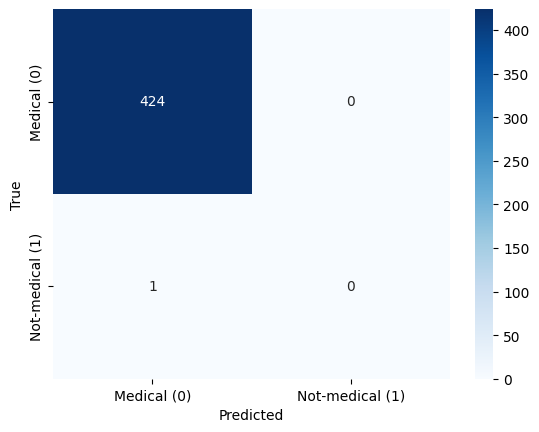

In [17]:
# Step 3H — Evaluate model performance
y_pred = clf.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, zero_division=0))

print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Medical (0)", "Not-medical (1)"],
            yticklabels=["Medical (0)", "Not-medical (1)"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


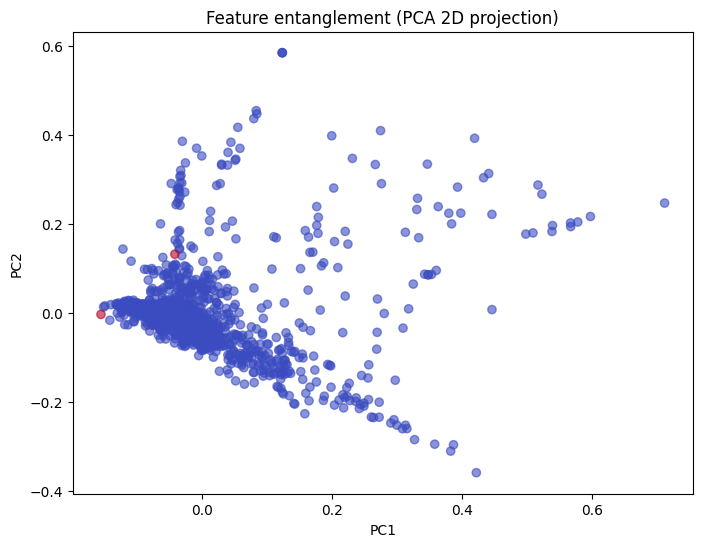

In [19]:
# Step 3I — Feature entanglement (PCA 2D plot)
X_features = vectorizer.fit_transform(df["query"])
X_reduced = PCA(n_components=2).fit_transform(X_features.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=df["label"], cmap="coolwarm", alpha=0.6)
plt.title("Feature entanglement (PCA 2D projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()